# Hierarchical Clustering

Hierarchical Clustering is an unsupervised learning algorithm used to group similar observations into clusters.

Unlike K-Means, Hierarchical Clustering builds a hierarchy of clusters.

The hierarchy can be visualized using a **Dendrogram**.

### Main Types

1. Agglomerative Clustering
2. Divisive Clustering

Scikit-Learn mainly provides Agglomerative Clustering.

### Basic Workflow

Dataset
   ↓
Feature Selection
   ↓
Handle Missing Values
   ↓
Feature Scaling
   ↓
Calculate Distances
   ↓
Build Hierarchy
   ↓
Dendrogram
   ↓
Choose Number of Clusters
   ↓
Agglomerative Clustering
   ↓
Evaluate Clusters

# Agglomerative Clustering

Agglomerative Clustering is a bottom-up hierarchical clustering algorithm.

Initially, every observation is treated as its own cluster.

Then the algorithm repeatedly combines the most similar clusters.

### Process

Initially:

```text
A   B   C   D   E

In [28]:
import seaborn as sns
df = sns.load_dataset("penguins")

df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


In [29]:
df.shape

(344, 7)

In [30]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    str    
 1   island             344 non-null    str    
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    str    
dtypes: float64(4), str(3)
memory usage: 24.9 KB


In [31]:
df.describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,200.915205,4201.754386
std,5.459584,1.974793,14.061714,801.954536
min,32.100000,13.100000,172.000000,2700.000000
25%,39.225000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


In [32]:
df.isnull().sum()

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

In [33]:
features = [
    "bill_length_mm",
    "bill_depth_mm",
    "flipper_length_mm",
    "body_mass_g"
]

X = df[features].dropna()

X.head()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
0,39.1,18.7,181.0,3750.0
1,39.5,17.4,186.0,3800.0
2,40.3,18.0,195.0,3250.0
4,36.7,19.3,193.0,3450.0
5,39.3,20.6,190.0,3650.0


In [34]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled[:5]

array([[-0.88449874,  0.78544923, -1.41834665, -0.56414208],
       [-0.81112573,  0.1261879 , -1.06225022, -0.50170305],
       [-0.66437972,  0.43046236, -0.42127665, -1.18853234],
       [-1.32473679,  1.08972369, -0.56371522, -0.93877623],
       [-0.84781224,  1.74898502, -0.77737308, -0.68902013]])

In [35]:
from scipy.cluster.hierarchy import linkage

linked = linkage(
    X_scaled,
    method="ward"
)

linked[:5]

array([[2.25000000e+02, 3.11000000e+02, 1.08991018e-01, 2.00000000e+00],
       [2.60000000e+02, 3.12000000e+02, 1.08991018e-01, 2.00000000e+00],
       [3.50000000e+01, 1.06000000e+02, 1.26537458e-01, 2.00000000e+00],
       [2.66000000e+02, 3.02000000e+02, 1.31843434e-01, 2.00000000e+00],
       [7.50000000e+01, 1.42000000e+02, 1.32965177e-01, 2.00000000e+00]])

# Dendrogram

A dendrogram is a tree-like diagram that shows how observations or clusters are progressively merged.

It helps us understand the hierarchical structure of the data and choose a reasonable number of clusters.

### Important

The vertical axis represents the distance at which clusters are merged.

A larger vertical jump can indicate a useful place to cut the dendrogram.

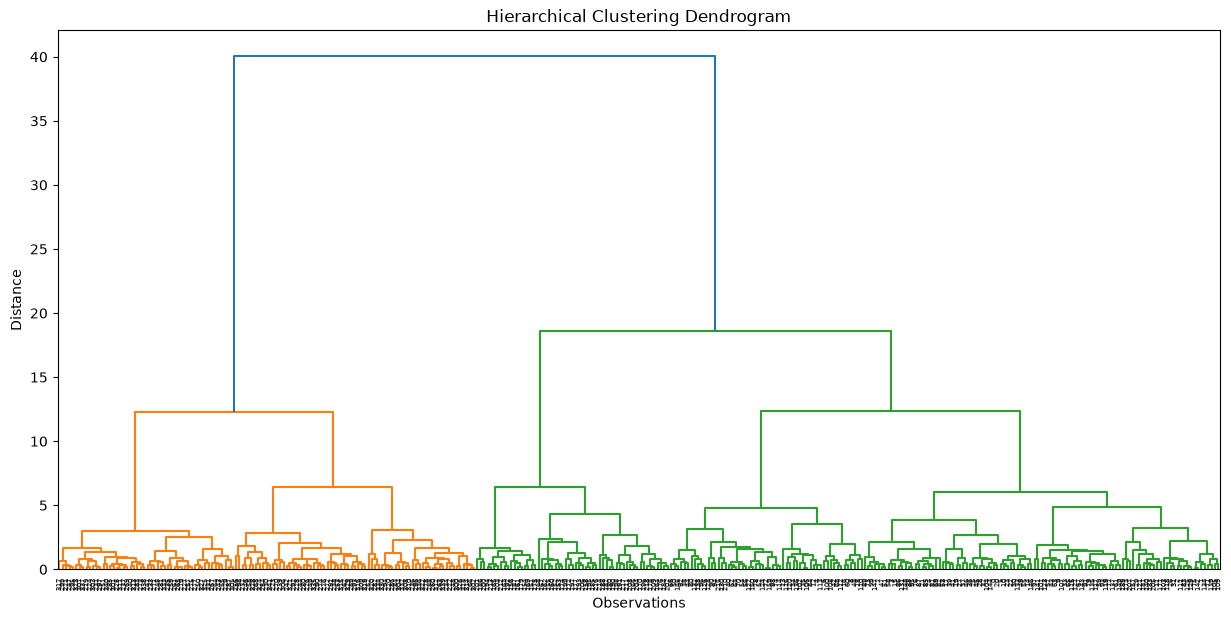

In [36]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram

plt.figure(figsize=(15, 7))

dendrogram(
    linked
)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Observations")
plt.ylabel("Distance")

plt.show()

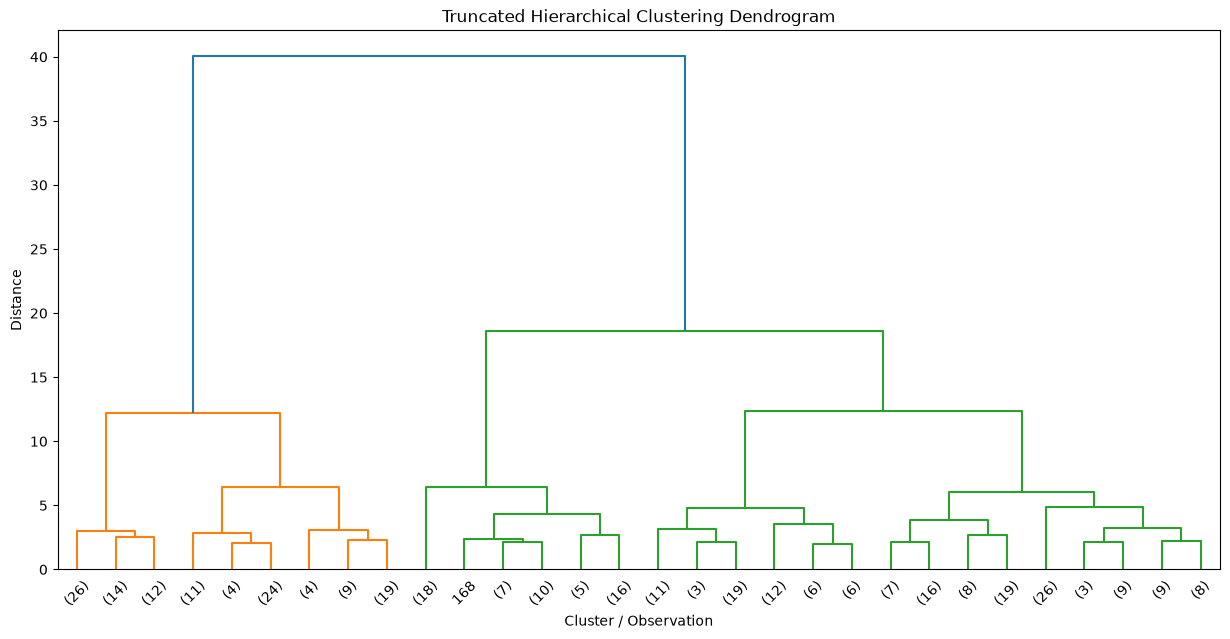

In [37]:
plt.figure(figsize=(15, 7))

dendrogram(
    linked,
    truncate_mode="lastp",
    p=30
)

plt.title("Truncated Hierarchical Clustering Dendrogram")
plt.xlabel("Cluster / Observation")
plt.ylabel("Distance")

plt.show()

# Choosing the Number of Clusters

We can use the dendrogram to determine a reasonable number of clusters.

Imagine drawing a horizontal line across the dendrogram.

The number of vertical branches intersected by the line represents the number of clusters.

For this example, we will use:

$$
K = 3
$$

The value of K should ideally be supported by cluster evaluation methods rather than chosen blindly.

In [38]:
from sklearn.cluster import AgglomerativeClustering

hierarchical_model = AgglomerativeClustering(
    n_clusters=3,
    linkage="ward"
)

hierarchical_labels = hierarchical_model.fit_predict(
    X_scaled
)

hierarchical_labels[:20]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [39]:
result = X.copy()

result["Cluster"] = hierarchical_labels

result.head()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,Cluster
0,39.1,18.7,181.0,3750.0,0
1,39.5,17.4,186.0,3800.0,0
2,40.3,18.0,195.0,3250.0,0
4,36.7,19.3,193.0,3450.0,0
5,39.3,20.6,190.0,3650.0,0


In [40]:
result["Cluster"].value_counts().sort_index()

Cluster
0    162
1    123
2     57
Name: count, dtype: int64

In [41]:
cluster_summary = result.groupby(
    "Cluster"
)[features].mean()

cluster_summary

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
Cluster,,,,
0,39.150000,18.287654,189.901235,3675.771605
1,47.504878,14.982114,217.186992,5076.016260
2,49.752632,18.601754,197.105263,3810.087719


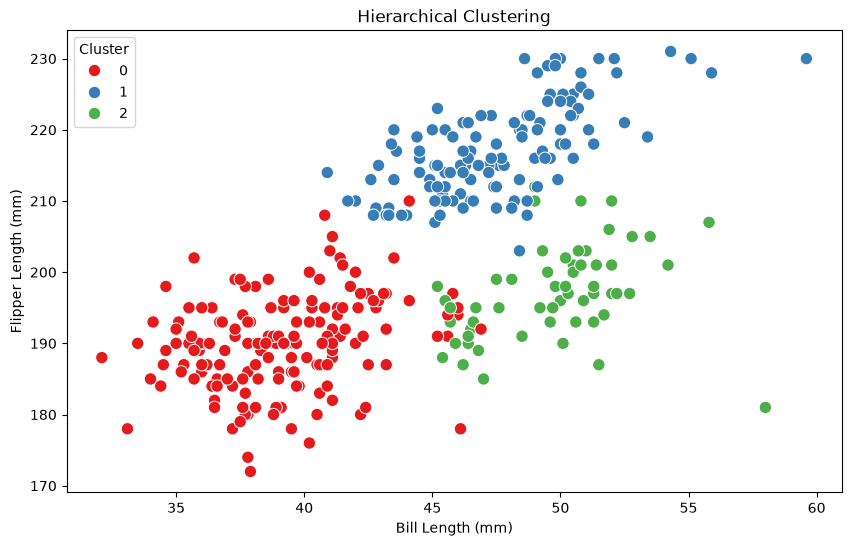

In [42]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=result,
    x="bill_length_mm",
    y="flipper_length_mm",
    hue="Cluster",
    palette="Set1",
    s=80
)

plt.title("Hierarchical Clustering")
plt.xlabel("Bill Length (mm)")
plt.ylabel("Flipper Length (mm)")

plt.show()

In [43]:
from sklearn.metrics import silhouette_score

silhouette = silhouette_score(
    X_scaled,
    hierarchical_labels
)

print(
    "Silhouette Score:",
    silhouette
)

Silhouette Score: 0.4540949927732963


In [44]:
silhouette_scores = []

for k in range(2, 11):

    model = AgglomerativeClustering(
        n_clusters=k,
        linkage="ward"
    )

    labels = model.fit_predict(
        X_scaled
    )

    score = silhouette_score(
        X_scaled,
        labels
    )

    silhouette_scores.append(score)

    print(
        f"K = {k}, Silhouette Score = {score:.4f}"
    )

K = 2, Silhouette Score = 0.5315
K = 3, Silhouette Score = 0.4541
K = 4, Silhouette Score = 0.4176
K = 5, Silhouette Score = 0.3632
K = 6, Silhouette Score = 0.3346
K = 7, Silhouette Score = 0.3054
K = 8, Silhouette Score = 0.2588
K = 9, Silhouette Score = 0.2635
K = 10, Silhouette Score = 0.2647


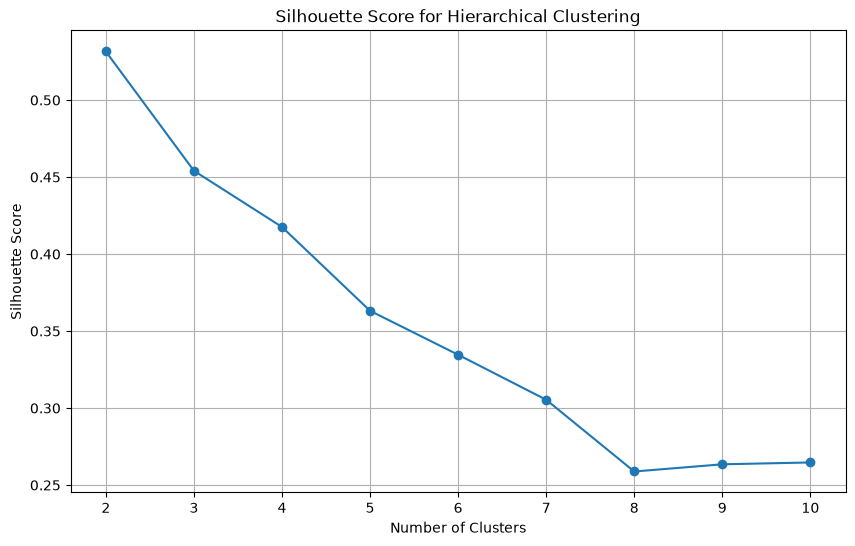

In [45]:
plt.figure(figsize=(10, 6))

plt.plot(
    range(2, 11),
    silhouette_scores,
    marker="o"
)

plt.title(
    "Silhouette Score for Hierarchical Clustering"
)

plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")

plt.grid()

plt.show()